In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import PlotStyler, ContinuousDynamicalSystem as cds

In [2]:
ds = cds(model="rossler system")

In [3]:
u0 = [0, 0.1, 0]
total_time = 2000
transient_time = 1000
num_intersections = 5000
c_range = (1, 10)
c = np.linspace(*c_range, 1000)
sampling_time = 1

In [4]:
parameters = [0.2, 0.2, 10]
ds.set_parameters(parameters)
trajectory = ds.trajectory(u0, total_time, transient_time=transient_time)
sm = ds.stroboscopic_map(u0, num_intersections, sampling_time, transient_time=transient_time)
mm = ds.maxima_map(u0, num_intersections, 2, transient_time=transient_time)

<Figure size 640x480 with 0 Axes>

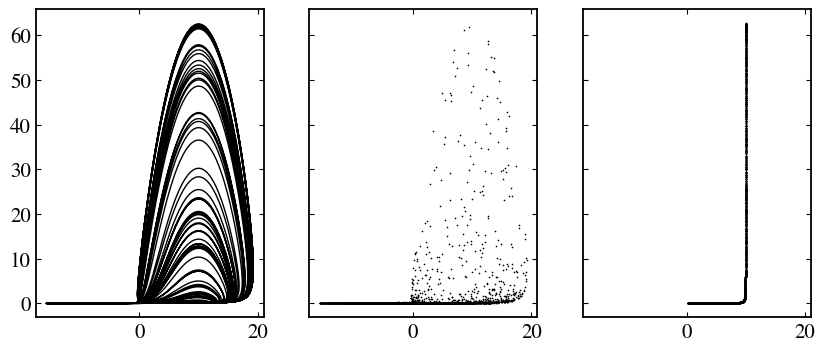

In [5]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 4))

ax[0].plot(trajectory[:, 1], trajectory[:, 3], "k")
ax[1].plot(sm[:, 1], sm[:, 3], "ko", ms=1.2, markeredgewidth=0)
ax[2].plot(mm[:, 1], mm[:, 3], "ko", ms=1.2, markeredgewidth=0)

In [6]:
ds.lyapunov(u0, total_time, transient_time=transient_time)

array([ 1.06567046e-01,  6.80248669e-04, -9.73884224e+00])

In [7]:
rte, recmat = ds.recurrence_time_entropy(u0, num_intersections, transient_time=transient_time, map_type="SM", sampling_time=sampling_time, return_recmat=True, threshold=0.1)

In [8]:
ds.recurrence_time_entropy(u0, num_intersections, transient_time=transient_time, map_type="SM", sampling_time=sampling_time, threshold=0.1, return_final_state=True)

(np.float64(5.271877893438826), array([-0.20564287,  1.36574226,  0.01986455]))

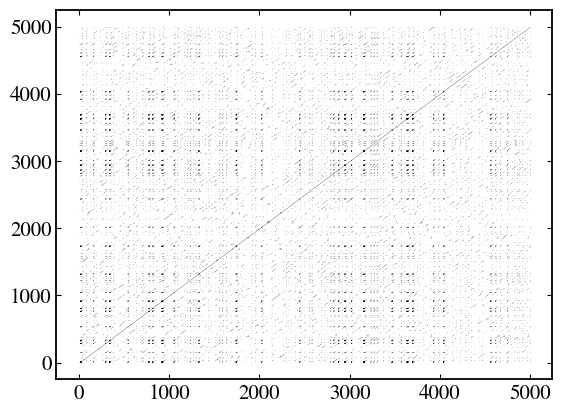

In [9]:
ii = np.where(recmat == 1)[0]
jj = np.where(recmat == 1)[1]
plt.plot(ii, jj, "ko", ms=0.1, markeredgewidth=0)
# plt.xlim(0, 100)
# plt.ylim(0, 100)

In [10]:
rte, recmat = ds.recurrence_time_entropy(u0, num_intersections, transient_time=transient_time, map_type="MM", maxima_index=2, return_recmat=True, threshold=0.01)

In [11]:
rte

np.float64(4.789937754869945)

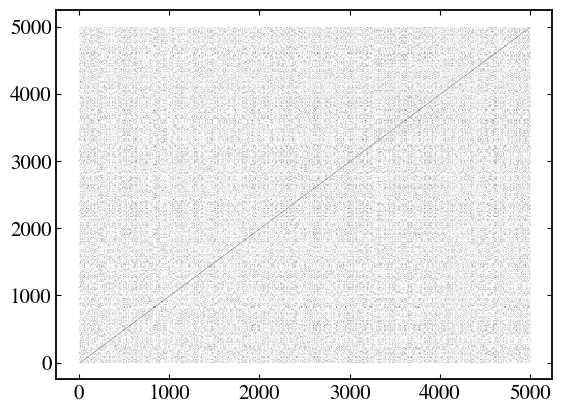

In [12]:
ii = np.where(recmat == 1)[0]
jj = np.where(recmat == 1)[1]
plt.plot(ii, jj, "ko", ms=0.1, markeredgewidth=0)
# plt.xlim(0, 100)
# plt.ylim(0, 100)

In [13]:
MLE = np.zeros_like(c)
for i in range(c.shape[0]):
    parameters = [0.2, 0.2, c[i]]
    ds.set_parameters(parameters)
    MLE[i] = ds.lyapunov(u0, total_time, transient_time=transient_time, num_exponents=1)[0]

In [14]:
RTE = np.zeros_like(c)
for i in range(c.shape[0]):
    parameters = [0.2, 0.2, c[i]]
    RTE[i] = ds.recurrence_time_entropy(u0, num_intersections, parameters=parameters, transient_time=transient_time, sampling_time=sampling_time)

<Figure size 640x480 with 0 Axes>

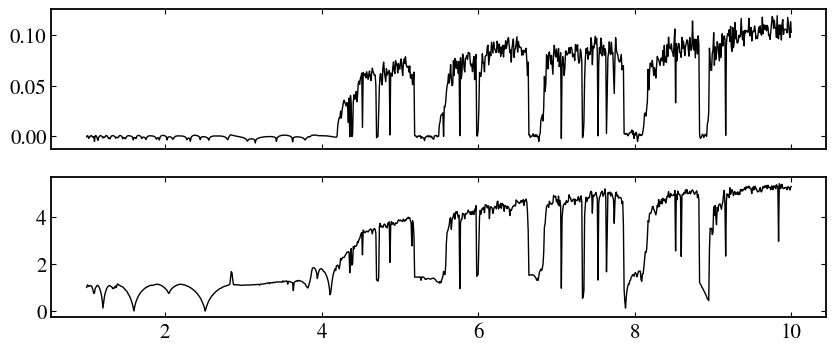

In [15]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 4))

ax[0].plot(c, MLE, "k-")
ax[1].plot(c, RTE, "k-")

In [16]:
ds = cds(model="rossler system")

In [17]:
trajectory = ds.trajectory(u0, total_time, transient_time=transient_time)

ValueError: This system expects 3 parameter(s), but got None.